<a href="https://colab.research.google.com/github/kjs444642-alt/deep-learning-project/blob/main/%EA%B8%B0%EB%A7%90%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
model = BetterCNN()

model.load_state_dict(
    torch.load("crack_cnn.pth")
)

model.eval()

print("데이터 증강 O 모델 불러오기 완료")

In [ ]:
model_no_aug = BetterCNN()

model_no_aug.load_state_dict(
    torch.load("crack_cnn_no_aug.pth")
)

model_no_aug.eval()

print("데이터 증강 X 모델 불러오기 완료")

### 1주차: 데이터 준비 및 환경 구축
* 데이터 구조 파악 (Positive / Negative 분류)
* 샘플 이미지 확인 및 데이터 크기 분석
* 프로젝트 전체 설계 및 모델 구조 초안 작성

In [1]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [2]:
import zipfile

with zipfile.ZipFile('/content/archive.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

In [3]:
import os
os.listdir('/content/')

['.config', 'Positive', 'archive.zip', 'Negative', 'sample_data']

In [4]:
import os

positive_dir = '/content/Positive'
negative_dir = '/content/Negative'

print("Positive 개수:", len(os.listdir(positive_dir)))
print("Negative 개수:", len(os.listdir(negative_dir)))

Positive 개수: 20000
Negative 개수: 20000


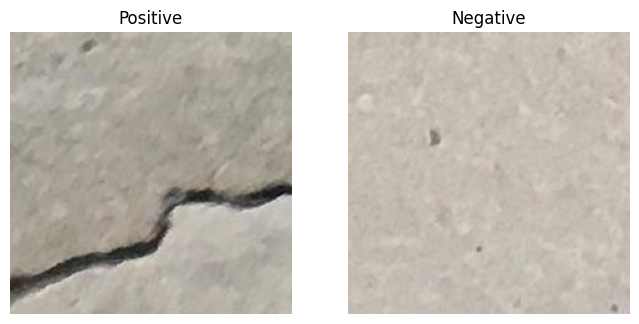

In [5]:
import matplotlib.pyplot as plt
import random
from PIL import Image

sample_pos = random.choice(os.listdir(positive_dir))
sample_neg = random.choice(os.listdir(negative_dir))

img1 = Image.open(os.path.join(positive_dir, sample_pos))
img2 = Image.open(os.path.join(negative_dir, sample_neg))

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img1)
plt.title("Positive")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img2)
plt.title("Negative")
plt.axis('off')

plt.show()

In [6]:
sample_img = Image.open(os.path.join(positive_dir, os.listdir(positive_dir)[0]))
print(sample_img.size) #이미지 사이즈

(227, 227)


### 2주차: 데이터 전처리 및 모델 설계
* 이미지 크기 통일 및 정규화 수행
* 데이터 증강(Data Augmentation) 적용 (회전, 좌우 반전, 밝기 변화 등)
* CNN 모델 구조 설계 (Conv2D, MaxPooling, BatchNorm, Dense Layer 구성)
* 학습 / 검증 데이터 분할

In [8]:
# =========================
# 이미지 크기 통일 및 정규화
# =========================

from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((128, 128)),   # 이미지 크기 통일
    transforms.ToTensor(),           # 텐서 변환
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],        # 정규화
        std=[0.5, 0.5, 0.5]
    )
])

print("이미지 전처리 및 정규화 완료")

이미지 전처리 및 정규화 완료


In [9]:
# =========================
# 데이터 증강 (Data Augmentation)
# =========================

from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((128, 128)),          # 이미지 크기 통일

    transforms.RandomHorizontalFlip(),      # 좌우 반전

    transforms.RandomRotation(10),          # 이미지 회전

    transforms.ColorJitter(
        brightness=0.2                      # 밝기 변화
    ),

    transforms.ToTensor(),                  # 텐서 변환

    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

print("데이터 증강 적용 완료")

데이터 증강 적용 완료


In [10]:
# =========================
# CNN 모델 구조 설계
# =========================

import torch
import torch.nn as nn

class BetterCNN(nn.Module):
    def __init__(self):
        super(BetterCNN, self).__init__()

        # 특징 추출 부분
        self.features = nn.Sequential(

            # Conv Block 1
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Conv Block 2
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Conv Block 3
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # 분류 부분 (Dense Layer)
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# 모델 생성
model = BetterCNN()

print(model)

BetterCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=(1, 1))
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=128, out_features=2

In [11]:
import os
os.listdir('/content/')

['.config', 'Positive', 'archive.zip', 'Negative', 'sample_data']

In [12]:
import os
import shutil

# 새 폴더 생성
os.makedirs('/content/crack_dataset', exist_ok=True)

# Positive / Negative 이동
shutil.move('/content/Positive', '/content/crack_dataset/Positive')
shutil.move('/content/Negative', '/content/crack_dataset/Negative')

print("폴더 정리 완료")

폴더 정리 완료


In [13]:
# =========================
# 데이터셋 불러오기 및 분할
# =========================

from torchvision import datasets
from torch.utils.data import random_split, DataLoader

dataset = datasets.ImageFolder(
    root='/content/crack_dataset',
    transform=transform
)

# 학습 80% / 검증 20%
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size]
)

# DataLoader 생성
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

print("전체 데이터 개수:", len(dataset))
print("학습 데이터 개수:", len(train_dataset))
print("검증 데이터 개수:", len(val_dataset))

print("클래스:", dataset.classes)

전체 데이터 개수: 40000
학습 데이터 개수: 32000
검증 데이터 개수: 8000
클래스: ['Negative', 'Positive']


### 3주차: 모델 학습 및 성능 평가
* CNN 모델 학습 진행
* 손실 함수 및 정확도 변화 확인
* 과적합 방지를 위한 하이퍼파라미터 조정 (learning rate, batch size 등)
* 데이터 증강 효과 비교 분석
* 모델 성능 평가 (Accuracy, Loss)

In [14]:
# =========================
# CNN 모델 학습
# =========================

import torch
import torch.nn as nn
import torch.optim as optim

# GPU 사용 가능하면 GPU 사용
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 모델 GPU로 이동
model = model.to(device)

# 손실 함수
criterion = nn.CrossEntropyLoss()

# 최적화 함수
optimizer = optim.Adam(model.parameters(), lr=0.001)

# epoch 설정
epochs = 5

# 학습 시작
for epoch in range(epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # 기울기 초기화
        optimizer.zero_grad()

        # 예측
        outputs = model(images)

        # 손실 계산
        loss = criterion(outputs, labels)

        # 역전파
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        running_loss += loss.item()

        # 정확도 계산
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"Loss: {running_loss:.4f}")
    print(f"Accuracy: {accuracy:.2f}%")
    print("------------------------")

Epoch [1/5]
Loss: 95.7112
Accuracy: 97.02%
------------------------
Epoch [2/5]
Loss: 41.3565
Accuracy: 98.70%
------------------------
Epoch [3/5]
Loss: 36.0120
Accuracy: 98.95%
------------------------
Epoch [4/5]
Loss: 26.3202
Accuracy: 99.20%
------------------------
Epoch [5/5]
Loss: 22.0423
Accuracy: 99.35%
------------------------


In [15]:
# =========================
# 학습된 모델 저장
# =========================

torch.save(model.state_dict(), "crack_cnn.pth")

print("모델 저장 완료")

모델 저장 완료


Epoch가 증가할수록 Loss 값은 감소하고 Accuracy는 증가하는 경향을 확인하였다. 이를 통해 모델이 균열 이미지의 특징을 점진적으로 학습하고 있음을 확인하였다.

In [16]:
# =========================
# Validation 성능 평가
# =========================

model.eval()

correct = 0
total = 0
val_loss = 0.0

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)
        val_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print("Validation Loss:", round(val_loss, 4))
print("Validation Accuracy:", round(accuracy, 2), "%")

Validation Loss: 3.8138
Validation Accuracy: 99.6 %


Validation 데이터셋을 이용하여 모델 성능을 평가한 결과, 약 99.6%의 높은 정확도를 확인하였다. 이를 통해 CNN 모델이 콘크리트 균열 이미지의 특징을 효과적으로 학습하였음을 확인할 수 있었다.(데이터증강O)

In [17]:
# =========================
# 데이터 증강 없는 전처리
# =========================

from torchvision import transforms

transform_no_aug = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

print("데이터 증강 제거 완료")

데이터 증강 제거 완료


In [18]:
# =========================
# 데이터셋 다시 불러오기
# =========================

from torchvision import datasets
from torch.utils.data import random_split, DataLoader

dataset_no_aug = datasets.ImageFolder(
    root='/content/crack_dataset',
    transform=transform_no_aug
)

train_size = int(0.8 * len(dataset_no_aug))
val_size = len(dataset_no_aug) - train_size

train_dataset_no_aug, val_dataset_no_aug = random_split(
    dataset_no_aug,
    [train_size, val_size]
)

train_loader_no_aug = DataLoader(
    train_dataset_no_aug,
    batch_size=32,
    shuffle=True
)

val_loader_no_aug = DataLoader(
    val_dataset_no_aug,
    batch_size=32,
    shuffle=False
)

print("데이터셋 준비 완료")

데이터셋 준비 완료


In [19]:
# =========================
# 새 CNN 모델 생성
# =========================

model_no_aug = BetterCNN().to(device)

print("새 모델 생성 완료")

새 모델 생성 완료


In [20]:
# =========================
# 데이터 증강 없이 학습
# =========================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model_no_aug.parameters(),
    lr=0.001
)

epochs = 5

for epoch in range(epochs):

    model_no_aug.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader_no_aug:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model_no_aug(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"Loss: {running_loss:.4f}")
    print(f"Accuracy: {accuracy:.2f}%")
    print("------------------------")

Epoch [1/5]
Loss: 64.4116
Accuracy: 98.23%
------------------------
Epoch [2/5]
Loss: 30.3696
Accuracy: 99.12%
------------------------
Epoch [3/5]
Loss: 20.6734
Accuracy: 99.40%
------------------------
Epoch [4/5]
Loss: 22.8500
Accuracy: 99.37%
------------------------
Epoch [5/5]
Loss: 20.7809
Accuracy: 99.43%
------------------------


In [21]:
# =========================
# Validation 평가
# =========================

model_no_aug.eval()

correct = 0
total = 0
val_loss = 0.0

with torch.no_grad():

    for images, labels in val_loader_no_aug:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model_no_aug(images)

        loss = criterion(outputs, labels)

        val_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print("Validation Loss:", round(val_loss, 4))
print("Validation Accuracy:", round(accuracy, 2), "%")

Validation Loss: 4.664
Validation Accuracy: 99.41 %


In [22]:
# =========================
# 데이터 증강 없는 모델 저장
# =========================

torch.save(
    model_no_aug.state_dict(),
    "crack_cnn_no_aug.pth"
)

print("데이터 증강 없는 모델 저장 완료")

데이터 증강 없는 모델 저장 완료


| 조건       | Validation Accuracy | Validation Loss |
| -------- | ------------------- | --------------- |
| 데이터 증강 O | 99.6%               | 3.8138          |
| 데이터 증강 X | 99.41%              | 4.664           |


데이터 증강(Data Augmentation)을 적용한 모델은 적용하지 않은 모델보다 더 높은 Accuracy와 더 낮은 Loss 값을 보였다. 이를 통해 데이터 증강이 모델의 일반화 성능 향상에 긍정적인 영향을 미쳤음을 확인할 수 있었다.